In [1]:
import os
import numpy as np
import librosa
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
URBAN_LABELS = {
    0: "air_conditioner",
    1: "car_horn",
    2: "children_playing",
    3: "dog_bark",
    4: "drilling",
    5: "engine_idling",
    6: "gun_shot",
    7: "jackhammer",
    8: "siren",
    9: "street_music"
}


In [3]:
def extract_features(file_path):
    try:
        y, sr = librosa.load(file_path, sr=16000, duration=4)
        y = librosa.util.normalize(y)

        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfcc = np.mean(mfcc, axis=1)

        return mfcc

    except:
        return None

In [4]:
X_urban = np.load(r"D:\sound_project\data\X_urban.npy")
y_urban = np.load(r"D:\sound_project\data\y_urban.npy")

X_esc = np.load(r"D:\sound_project\data\X_esc50.npy")
y_esc = np.load(r"D:\sound_project\data\y_esc50.npy")

print("Urban:", X_urban.shape)
print("ESC:", X_esc.shape)

Urban: (8732, 13)
ESC: (2000, 13)


In [5]:
def analyze_confusion(cm):
    print("Phân tích lỗi:")

    errors = []
    for i in range(len(cm)):
        for j in range(len(cm)):
            if i != j and cm[i][j] > 0:
                errors.append((cm[i][j], i, j))

    errors = sorted(errors, reverse=True)[:5]

    for count, true, pred in errors:
        print(f"- Nhầm {true} → {pred}: {count} lần")

In [6]:
def plot_confusion(y_true, y_pred, title):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    if "ESC" in title:
        sns.heatmap(cm, cmap="Blues")
    else:
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    analyze_confusion(cm)

In [7]:
def train_models(X, y, name):

    print(f"\n===== {name} =====")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    results = {}

    # ===== KNN =====
    knn = KNeighborsClassifier(n_neighbors=5, weights='distance')
    knn.fit(X_train, y_train)

    y_pred_knn = knn.predict(X_test)
    acc_knn = accuracy_score(y_test, y_pred_knn)

    print("\n--- KNN ---")
    print("Accuracy:", round(acc_knn, 4))
    print(classification_report(y_test, y_pred_knn))

    plot_confusion(y_test, y_pred_knn, f"{name} - KNN")

    results["KNN"] = (knn, acc_knn)

    # ===== SVM =====
    svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True)
    svm.fit(X_train, y_train)

    y_pred_svm = svm.predict(X_test)
    acc_svm = accuracy_score(y_test, y_pred_svm)

    print("\n--- SVM ---")
    print("Accuracy:", round(acc_svm, 4))
    print(classification_report(y_test, y_pred_svm))

    plot_confusion(y_test, y_pred_svm, f"{name} - SVM")

    results["SVM"] = (svm, acc_svm)

    return results, scaler


===== UrbanSound8K =====

--- KNN ---
Accuracy: 0.8838
                  precision    recall  f1-score   support

 air_conditioner       0.88      0.97      0.92       200
        car_horn       0.95      0.72      0.82        86
children_playing       0.85      0.84      0.84       200
        dog_bark       0.92      0.76      0.83       200
        drilling       0.91      0.89      0.90       200
   engine_idling       0.92      0.97      0.94       200
        gun_shot       0.88      0.79      0.83        75
      jackhammer       0.90      0.93      0.92       200
           siren       0.94      0.97      0.96       186
    street_music       0.76      0.85      0.80       200

        accuracy                           0.88      1747
       macro avg       0.89      0.87      0.88      1747
    weighted avg       0.89      0.88      0.88      1747



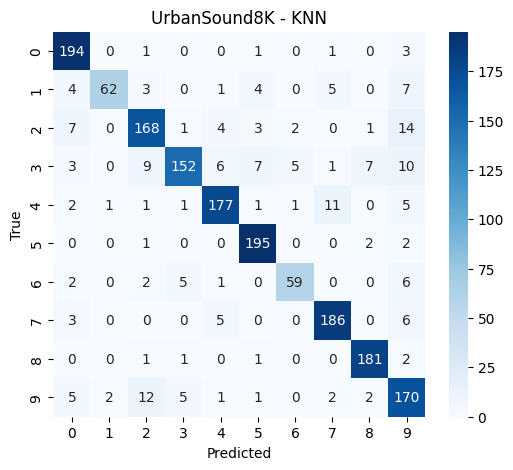

Phân tích lỗi:
- Nhầm 2 → 9: 14 lần
- Nhầm 9 → 2: 12 lần
- Nhầm 4 → 7: 11 lần
- Nhầm 3 → 9: 10 lần
- Nhầm 3 → 2: 9 lần

--- SVM ---
Accuracy: 0.8477
                  precision    recall  f1-score   support

 air_conditioner       0.86      0.94      0.89       200
        car_horn       0.83      0.72      0.77        86
children_playing       0.76      0.78      0.77       200
        dog_bark       0.83      0.77      0.79       200
        drilling       0.91      0.87      0.89       200
   engine_idling       0.89      0.93      0.91       200
        gun_shot       0.86      0.79      0.82        75
      jackhammer       0.88      0.87      0.88       200
           siren       0.96      0.95      0.95       186
    street_music       0.73      0.77      0.75       200

        accuracy                           0.85      1747
       macro avg       0.85      0.84      0.84      1747
    weighted avg       0.85      0.85      0.85      1747



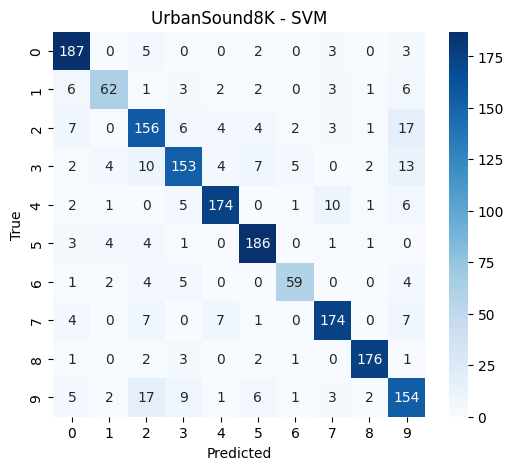

Phân tích lỗi:
- Nhầm 9 → 2: 17 lần
- Nhầm 2 → 9: 17 lần
- Nhầm 3 → 9: 13 lần
- Nhầm 4 → 7: 10 lần
- Nhầm 3 → 2: 10 lần

===== ESC-50 =====

--- KNN ---
Accuracy: 0.4175
                  precision    recall  f1-score   support

        airplane       0.44      0.50      0.47         8
       breathing       0.33      0.12      0.18         8
  brushing_teeth       0.25      0.25      0.25         8
     can_opening       0.25      0.38      0.30         8
        car_horn       0.40      0.25      0.31         8
             cat       0.50      0.50      0.50         8
        chainsaw       0.20      0.12      0.15         8
  chirping_birds       1.00      0.50      0.67         8
    church_bells       0.60      0.38      0.46         8
        clapping       0.62      0.62      0.62         8
     clock_alarm       0.75      0.75      0.75         8
      clock_tick       0.17      0.12      0.14         8
        coughing       0.17      0.25      0.20         8
             cow 

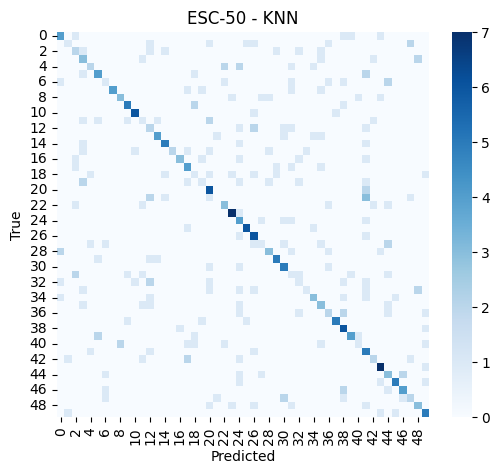

Phân tích lỗi:
- Nhầm 21 → 41: 3 lần
- Nhầm 47 → 30: 2 lần
- Nhầm 46 → 38: 2 lần
- Nhầm 44 → 46: 2 lần
- Nhầm 42 → 17: 2 lần

--- SVM ---
Accuracy: 0.49
                  precision    recall  f1-score   support

        airplane       0.40      0.25      0.31         8
       breathing       0.25      0.25      0.25         8
  brushing_teeth       0.38      0.38      0.38         8
     can_opening       0.57      0.50      0.53         8
        car_horn       0.44      0.50      0.47         8
             cat       0.42      0.62      0.50         8
        chainsaw       0.29      0.25      0.27         8
  chirping_birds       0.71      0.62      0.67         8
    church_bells       0.50      0.50      0.50         8
        clapping       0.56      0.62      0.59         8
     clock_alarm       0.46      0.75      0.57         8
      clock_tick       0.00      0.00      0.00         8
        coughing       0.25      0.25      0.25         8
             cow       0.57      0

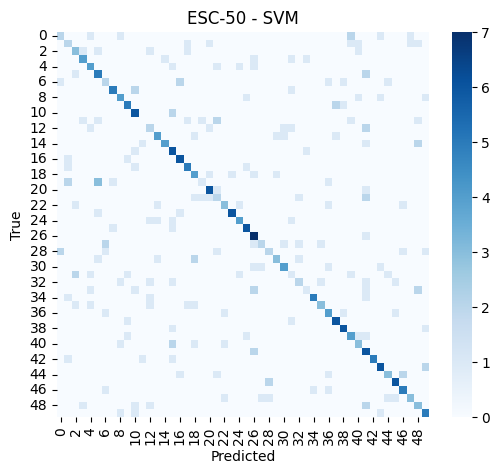

Phân tích lỗi:
- Nhầm 19 → 5: 3 lần
- Nhầm 48 → 41: 2 lần
- Nhầm 45 → 28: 2 lần
- Nhầm 44 → 46: 2 lần
- Nhầm 43 → 49: 2 lần


In [8]:
urban_results, urban_scaler = train_models(X_urban, y_urban, "UrbanSound8K")
esc_results, esc_scaler = train_models(X_esc, y_esc, "ESC-50")

In [10]:
# ===== CHỌN MODEL CHÍNH (KNN) =====
main_model = urban_results["KNN"][0]
main_scaler = urban_scaler
main_name = "Urban - KNN"

# ===== MODEL SO SÁNH (SVM) =====
svm_model = urban_results["SVM"][0]
svm_scaler = urban_scaler

print("Model chính:", main_name)
print("Model so sánh:", "Urban - SVM")

Model chính: Urban - KNN
Model so sánh: Urban - SVM


In [14]:
# ===== SAVE MODEL CHÍNH (KNN) =====
joblib.dump(main_model, "knn_model.pkl")
joblib.dump(main_scaler, "knn_scaler.pkl")

# ===== SAVE MODEL SO SÁNH (SVM) =====
joblib.dump(svm_model, "svm_model.pkl")
joblib.dump(svm_scaler, "svm_scaler.pkl")

print("Saved all models")

Saved all models


In [15]:
def demo(file_path):

    features = extract_features(file_path)

    if features is None:
        print("Feature lỗi")
        return

    features = features.reshape(1, -1)

    # ===== KNN =====
    f_knn = main_scaler.transform(features)
    pred_knn = main_model.predict(f_knn)[0]
    conf_knn = np.max(main_model.predict_proba(f_knn)[0])

    # ===== SVM =====
    f_svm = svm_scaler.transform(features)
    pred_svm = svm_model.predict(f_svm)[0]
    conf_svm = np.max(svm_model.predict_proba(f_svm)[0])

    print("DEMO:")
    print("File:", file_path)
    print("KNN (Model chính):", pred_knn)
    print("Confidence:", conf_knn)

    print("SVM (So sánh):", pred_svm)
    print("Confidence:", conf_svm)

In [16]:
file_test = r"D:\sound_project\data\fold8\31325-3-1-1.wav"
demo(file_test)

c:\Users\Lê Đình Quý\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DEMO:
File: D:\sound_project\data\fold8\31325-3-1-1.wav
KNN (Model chính): dog_bark
Confidence: 0.6505845433487564
SVM (So sánh): dog_bark
Confidence: 0.787861403950772


In [17]:
file_test = r"D:\sound_project\data\ESC-50-master\ESC-50-master\audio\4-209698-A-37.wav"
demo(file_test)

DEMO:
File: D:\sound_project\data\ESC-50-master\ESC-50-master\audio\4-209698-A-37.wav
KNN (Model chính): drilling
Confidence: 0.6229836659597053
SVM (So sánh): drilling
Confidence: 0.8021914130352279


In [18]:
file_test = r"D:\sound_project\data\ESC-50-master\ESC-50-master\audio\4-213915-A-3.wav"
demo(file_test)

DEMO:
File: D:\sound_project\data\ESC-50-master\ESC-50-master\audio\4-213915-A-3.wav
KNN (Model chính): air_conditioner
Confidence: 0.7971704076567291
SVM (So sánh): street_music
Confidence: 0.6975479224555104


In [19]:
file_test = r"D:\sound_project\data\ESC-50-master\ESC-50-master\audio\5-160551-A-42.wav"
demo(file_test)

DEMO:
File: D:\sound_project\data\ESC-50-master\ESC-50-master\audio\5-160551-A-42.wav
KNN (Model chính): siren
Confidence: 0.42068738413055373
SVM (So sánh): siren
Confidence: 0.8442189854509181


In [20]:
file_test = r"D:\sound_project\data\ESC-50-master\ESC-50-master\audio\5-178997-A-24.wav"
demo(file_test)

DEMO:
File: D:\sound_project\data\ESC-50-master\ESC-50-master\audio\5-178997-A-24.wav
KNN (Model chính): engine_idling
Confidence: 0.7757411769055289
SVM (So sánh): gun_shot
Confidence: 0.515061734408738
